# 03 – EMG-Signalverarbeitungs-Pipeline

**Basierend auf:** Ellenberger et al. (2021) – *Thigh muscle activation patterns and dynamic knee valgus at peak ground reaction force during drop jump landings*

### Pipeline-Schritte
1. **Laden** der preprocessed `*_emg.csv` Dateien (EMG bei voller Analog-Rate)
2. **Resampling** auf einheitliche 2000 Hz (falls nötig, z.B. von 2100 Hz)
3. **Artefaktentfernung** – Werte > 5× Standardabweichung des Rohsignals
4. **Rectifizierung** – Gleichrichtung (Absolutwert)
5. **Bandpassfilter** – 4. Ordnung Zero-Lag Butterworth, 20–500 Hz
6. **RMS-Glättung** – 30 ms symmetrisches gleitendes Fenster
7. **Normalisierung** – auf Peak-RMS-Aktivierung des bilateralen Squats (BILATERAL, R-Seite, analog MVC)
8. **Zeitnormalisierung** – 101 Punkte (0–100 %)

### Übungen und Seiten
| Übung | Seite | Ausgewertetes Bein |
|-------|-------|--------------------|
| CMJ | BILATERAL | Rechts |
| CMJ | RIGHT | Rechts |
| DJ | BILATERAL | Rechts |
| SQ | BILATERAL | Rechts (Baseline) |
| SQ | RIGHT | Rechts (Auswertung) |

In [1]:
# ─── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, resample_poly
from scipy.interpolate import interp1d
from pathlib import Path
from math import gcd
import warnings
warnings.filterwarnings('ignore')
import sys
from pathlib import Path

# Projektroot zum Python-Pfad hinzufügen (dort wo scripts/ liegt)
PROJECT_ROOT = Path(r'C:\Users\Greta\OneDrive\Desktop\MCI\3-SS2026\BA\BA_Daten_EMG')
sys.path.insert(0, str(PROJECT_ROOT))

from scripts.utils.config import (
    BASELINE_MODE, BASELINE_FOLDERS, EXERCISE_CONFIGS,
    print_config,
)

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

MUSCLE_COLORS = {
    'Biceps Femoris':       '#e63946',
    'Gastrocnemius medial': '#457b9d',
    'Gluteus Medius':       '#2a9d8f',
    'Semitendinosus':       '#e9c46a',
    'Vastus Lateralis':     '#f4a261',
}

print('\u2705 Imports erfolgreich')

✅ Imports erfolgreich


In [2]:
# ─── Konfiguration ──────────────────────────────────────────────────────────────

# Basispfad zu den preprocessed Daten
DATA_ROOT = Path(r'C:\Users\Greta\OneDrive\Desktop\MCI\3-SS2026\BA\BA_Daten_EMG\data\03_preprocessed_emg_data')
OUTPUT_DIR = Path(r'C:\Users\Greta\OneDrive\Desktop\MCI\3-SS2026\BA\BA_Daten_EMG\data\04_processed_emg_data')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Ziel-Sampling-Rate (einheitlich für alle Subjects)
FS_TARGET = 2000  # Hz

# Zero-lag Butterworth-Filter (Ellenberger et al. 2021)
BP_LOW       = 20    # Hz
BP_HIGH      = 500   # Hz
FILTER_ORDER = 4

# RMS-Fenster (einziger Parameter, der nicht nach Ellenberger et al. 2021 gewählt wurde)
RMS_WINDOW_MS = 50   # ms

# Artefakt-Schwelle (Ellenberger et al. 2021)
ARTEFACT_SD_FACTOR = 5

# Zeitnormalisierung
N_NORM_POINTS = 101

# Muskelspalten (ohne L_ / R_ Prefix)
MUSCLE_NAMES = [
    'Biceps Femoris',
    'Gastrocnemius medial',
    'Gluteus Medius',
    'Semitendinosus',
    'Vastus Lateralis',
]

# Ausgewertete Seite
SIDE = 'R'

# Baseline
_baseline_ex, _baseline_side = BASELINE_FOLDERS[BASELINE_MODE]
 
print_config()

# Phasen
PHASES = ['01_PER', '02_OVU', '03_LUT']

# Subjects (alle Ordner im DATA_ROOT)
SUBJECTS = sorted([d.name for d in DATA_ROOT.iterdir() if d.is_dir()])

# Visualisierungs-Beispiel
VIZ_SUBJECT = SUBJECTS[0] if SUBJECTS else 'S01'
VIZ_PHASE   = '01_PER'
VIZ_EXERCISE = 'CMJ'
VIZ_SIDE_FOLDER = 'BILATERAL'

print('✅ Konfiguration gesetzt')
print(f'Subjects: {len(SUBJECTS)} ({SUBJECTS[0]}–{SUBJECTS[-1]})')
print(f'Ziel-fs: {FS_TARGET} Hz')
print(f'Seite: {SIDE}')

Baseline-Modus       : DJ (DJ/BILATERAL)
Baseline ausschließen: nein (wird mit ausgewertet)
Pipeline-Übungen     : ['CMJ bilateral', 'CMJ einbeinig', 'DJ bilateral', 'SQ bilateral', 'SQ einbeinig']
Trial-Selektion      : ['CMJ bilateral', 'CMJ einbeinig R', 'DJ bilateral', 'SQ bilateral', 'SQ einbeinig R']
Exercise-Map         : ['CMJ bilateral', 'CMJ einbeinig R', 'DJ bilateral', 'SQ bilateral', 'SQ einbeinig R']
✅ Konfiguration gesetzt
Subjects: 11 (S01–S11)
Ziel-fs: 2000 Hz
Seite: R


---
## Pipeline-Funktionen

In [3]:
# ─── Schritt 1+2: Laden und Resampling ────────────────────────────────────────

def load_emg(filepath: Path, fs_target: int = FS_TARGET) -> tuple[pd.DataFrame, int]:
    """
    Lädt eine *_emg.csv Datei.
    Erkennt die Sampling-Rate aus time_s und resampelt bei Bedarf auf fs_target.
    Gibt (DataFrame mit nur time_s + R_* EMG-Spalten, fs) zurück.
    """
    df = pd.read_csv(filepath)

    # Sampling-Rate aus Zeitstempeln erkennen
    dt = df['time_s'].diff().median()
    fs_detected = round(1.0 / dt) if dt > 0 else fs_target

    # Nur R_* EMG-Spalten behalten
    emg_cols = [f'{SIDE}_{m}' for m in MUSCLE_NAMES if f'{SIDE}_{m}' in df.columns]
    if not emg_cols:
        return pd.DataFrame(), fs_target

    df_out = df[['time_s'] + emg_cols].copy()

    # Resampling falls nötig
    if fs_detected != fs_target:
        g    = gcd(fs_target, fs_detected)
        up   = fs_target  // g
        down = fs_detected // g

        resampled = {}
        for col in emg_cols:
            resampled[col] = resample_poly(df_out[col].values, up, down)

        n_new = len(next(iter(resampled.values())))
        t_new = np.linspace(df_out['time_s'].iloc[0],
                            df_out['time_s'].iloc[-1], n_new)

        df_out = pd.DataFrame({'time_s': t_new})
        for col, arr in resampled.items():
            df_out[col] = arr

        return df_out, fs_target
    else:
        return df_out, fs_detected

In [4]:
# ─── Schritt 3: Artefaktentfernung ────────────────────────────────────────────

def remove_artefacts(df: pd.DataFrame,
                     sd_factor: float = ARTEFACT_SD_FACTOR) -> pd.DataFrame:
    """
    Entfernt EMG-Artefakte: Werte > sd_factor × SD des Rohsignals
    werden durch linear interpolierte Werte ersetzt.
    (Ellenberger et al. 2021)
    """
    df_out = df.copy()
    emg_cols = [c for c in df.columns if c != 'time_s']
    total_removed = 0

    for col in emg_cols:
        signal = df_out[col].values.copy()
        sd = np.std(signal)
        mask = np.abs(signal) > sd_factor * sd
        n_removed = mask.sum()
        total_removed += n_removed

        if n_removed > 0:
            # Artefakt-Samples durch NaN ersetzen, dann interpolieren
            signal[mask] = np.nan
            s = pd.Series(signal)
            s = s.interpolate(method='linear', limit_direction='both')
            df_out[col] = s.values

    return df_out, total_removed

In [5]:
# ─── Schritt 4: Rectifizierung ────────────────────────────────────────────────

def rectify(df: pd.DataFrame) -> pd.DataFrame:
    """Gleichrichtet alle EMG-Spalten (Absolutwert)."""
    df_out = df.copy()
    emg_cols = [c for c in df.columns if c != 'time_s']
    for col in emg_cols:
        df_out[col] = np.abs(df_out[col].values)
    return df_out

In [6]:
# ─── Schritt 5: Bandpassfilter ────────────────────────────────────────────────

def bandpass_filter(df: pd.DataFrame,
                    fs: int     = FS_TARGET,
                    low: float  = BP_LOW,
                    high: float = BP_HIGH,
                    order: int  = FILTER_ORDER) -> pd.DataFrame:
    """
    4. Ordnung Zero-Lag Butterworth Bandpassfilter.
    (Ellenberger et al. 2021)
    """
    nyq = fs / 2.0
    sos = butter(order, [low / nyq, high / nyq],
                 btype='bandpass', output='sos')

    df_out = df.copy()
    emg_cols = [c for c in df.columns if c != 'time_s']
    for col in emg_cols:
        df_out[col] = sosfiltfilt(sos, df_out[col].values)
    return df_out

In [7]:
# ─── Schritt 6: Hüllurve (Envelope) - RMS-Glättung ──────────────────────────────────────────────────

def rms_smooth(signal: np.ndarray, fs: int,
               window_ms: float = RMS_WINDOW_MS) -> np.ndarray:
    """
    Symmetrisches gleitendes RMS (30 ms).
    (Ellenberger et al. 2021)
    """
    win = int(round(window_ms / 1000.0 * fs))
    if win % 2 == 0:
        win += 1
    half = win // 2

    padded = np.pad(signal, half, mode='reflect') # alle Werte auf einmal quadrieren
    sq     = padded ** 2 # kumulative Summe
    cs     = np.concatenate([[0], np.cumsum(sq)])
    rms    = np.sqrt((cs[win:] - cs[:-win]) / win) # Differenz zweier Positionen
    return rms


def apply_rms_smooth(df: pd.DataFrame, fs: int) -> pd.DataFrame:
    df_out   = df.copy()
    emg_cols = [c for c in df.columns if c != 'time_s']
    for col in emg_cols:
        df_out[col] = rms_smooth(df_out[col].values, fs)
    return df_out

In [8]:
# Die Baseline wird PHASENSPEZIFISCH berechnet!
# Pro Probandin UND Phase → ein eigener Referenz-Trial (bester DJ der Phase).
# Hintergrund: Zwischen den Messterminen werden die Elektroden neu geklebt, daher können die absoluten Amplituden variieren.
#
# Baseline = Peak-RMS aus dem besten DJ-Trial INNERHALB der jeweiligen Phase

def _get_max_knee_angle(kin_path: Path) -> float:
    """Max. rechter Kniewinkel aus _kin.csv (= tiefster Squat)."""
    if not kin_path.exists():
        return np.nan
    df = pd.read_csv(kin_path, low_memory=False)
    if 'Right Knee Angles' not in df.columns:
        return np.nan
    vals = pd.to_numeric(df['Right Knee Angles'], errors='coerce').dropna()
    return float(vals.max()) if not vals.empty else np.nan


def _get_jumpheight(emg_path: Path) -> float:
    """Sprunghöhe aus der ersten Zeile der _emg.csv."""
    df = pd.read_csv(emg_path, nrows=1, low_memory=False)
    if 'Jumpheight' in df.columns:
        val = pd.to_numeric(df['Jumpheight'].iloc[0], errors='coerce')
        if pd.notna(val):
            return float(val)
    return np.nan


def _find_best_trial_in_phase(subject: str, phase: str,  exercise_folder: str,
                     side_folder: str) -> Path | None:
    """
    Findet den besten Trial INNERHALB einer PHASEN hinweg. Jenachdem, was ausgewählt ist: SQ oder DJ.

    SQ-Modus: Trial mit dem größten max. Kniewinkel (tiefster Squat)
    DJ-Modus: Trial mit der höchsten Sprunghöhe
    """

    trial_dir = DATA_ROOT / subject / phase / exercise_folder / side_folder
    if not trial_dir.exists():
        return None

    best_value = -np.inf
    best_path  = None

    emg_files = sorted(trial_dir.glob('*_emg.csv'))
    for emg_path in emg_files:
        if BASELINE_MODE == 'SQ':
            kin_path = emg_path.parent / emg_path.name.replace('_emg', '_kin')
            value = _get_max_knee_angle(kin_path)
        elif BASELINE_MODE == 'DJ':
            value = _get_jumpheight(emg_path)
        else:
            value = np.nan

        if pd.notna(value) and value > best_value:
            best_value = value
            best_path  = emg_path

    if best_path is not None:
        unit = '°' if BASELINE_MODE == 'SQ' else 'm'
        label = 'Kniewinkel' if BASELINE_MODE == 'SQ' else 'Sprunghöhe'
        print(f'    Bester {BASELINE_MODE}-Trial ({phase}): '
              f'{best_path.stem}  ({label} = {best_value:.3f} {unit})')

    return best_path


def compute_baseline(subject: str, phase: str,
                     fs_target: int = FS_TARGET) -> dict[str, float]:
    """
    Berechnet die Baseline-Aktivierung pro Muskel aus dem besten
    Referenz-Trial INNERHALB einer Phase.

    1. Findet den besten Trial der Phase(SQ: tiefster Squat, DJ: höchster Sprung)
    2. Schickt diesen durch Pipeline-Schritte 1–6
    3. Peak-RMS pro Muskel = 100% Baseline

    Gibt ein dict {Spaltenname: Peak-RMS-Wert} zurück.
    Dieser Wert gilt nur für die angegebene Phasen der Probandin.
    """
    exercise_folder, side_folder = BASELINE_FOLDERS[BASELINE_MODE]

    # Besten Trial der Phasen finden
    best_path = _find_best_trial_in_phase(subject, phase, exercise_folder, side_folder)

    if best_path is None:
        print(f'⚠️ Kein {BASELINE_MODE}-Trial gefunden für {subject} / {phase} ')
        return {}

    # Besten Trial durch Pipeline schicken (Schritte 1–6)
    df, fs = load_emg(best_path, fs_target)
    if df.empty:
        print(f'⚠️ Keine R-Daten in {best_path.name}')
        return {}

    df, _ = remove_artefacts(df)
    df = rectify(df)
    df = bandpass_filter(df, fs=fs)
    df = apply_rms_smooth(df, fs=fs)

    # Peak-RMS pro Muskel = 100% Baseline
    baseline = {}
    for col in [f'{SIDE}_{m}' for m in MUSCLE_NAMES]:
        if col in df.columns:
            baseline[col] = float(df[col].max())
        else:
            baseline[col] = np.nan

    # Ausgabe
    print(f'Baseline {phase} (Peak-RMS = 100 %):')
    for col, val in baseline.items():
        muscle = col.replace(f'{SIDE}_', '')
        if pd.notna(val):
            print(f'{muscle:25s}: {val:8.2f} µV')
        else:
            print(f'{muscle:25s}: – (keine Daten)')

    return baseline

def normalize_to_baseline(df: pd.DataFrame,
                          baseline: dict[str, float]) -> pd.DataFrame:
    """
    Normalisiert EMG-Daten als Prozent der Baseline-Aktivierung.
    """
    df_out = df.copy()
    for col in [c for c in df.columns if c != 'time_s']:
        bval = baseline.get(col, np.nan)
        if pd.notna(bval) and bval > 0:
            df_out[col] = (df_out[col] / bval) * 100.0
        else:
            df_out[col] = np.nan
    return df_out

In [9]:
# ─── Schritt 8: Zeitnormalisierung ────────────────────────────────────────────

def time_normalize(df: pd.DataFrame,
                   n_points: int = N_NORM_POINTS) -> pd.DataFrame:
    """
    Normalisiert alle EMG-Spalten auf n_points (0–100 %) mittels
    kubischer Interpolation.
    """
    t_orig   = df['time_s'].values
    t_norm   = np.linspace(t_orig[0], t_orig[-1], n_points)
    pct_axis = np.linspace(0, 100, n_points)

    emg_cols = [c for c in df.columns if c != 'time_s']

    out = {'pct': pct_axis}
    for col in emg_cols:
        f_interp = interp1d(t_orig, df[col].values,
                            kind='cubic', fill_value='extrapolate')
        out[col] = f_interp(t_norm)

    return pd.DataFrame(out)

In [10]:
# ─── Komplette Pipeline für eine Datei ────────────────────────────────────────

def process_trial(filepath: Path, baseline: dict[str, float],
                  fs_target: int = FS_TARGET,
                  return_steps: bool = False):
    """
    Wendet die komplette Pipeline auf einen Trial an.

    Returns:
        df_norm: zeitnormalisierter DataFrame (101 Punkte, % Baseline)
        fs: verwendete Sampling-Rate
        steps: dict mit Zwischenergebnissen (nur wenn return_steps=True)
    """
    steps = {}

    # 1+2: Laden + Resampling
    df_raw, fs = load_emg(filepath, fs_target)
    if df_raw.empty:
        return None, fs_target, {}
    steps['raw'] = df_raw.copy()

    # 3: Artefaktentfernung
    df_clean, n_art = remove_artefacts(df_raw)
    steps['clean'] = df_clean.copy()
    steps['n_artefacts'] = n_art

    # 4: Rectifizierung
    df_rect = rectify(df_clean)
    steps['rect'] = df_rect.copy()

    # 5: Bandpassfilter
    df_filt = bandpass_filter(df_rect, fs=fs)
    steps['filt'] = df_filt.copy()

    # 6: RMS-Glättung
    df_rms = apply_rms_smooth(df_filt, fs=fs)
    steps['rms'] = df_rms.copy()

    # 7: Normalisierung auf Baseline
    if baseline:
        df_normed = normalize_to_baseline(df_rms, baseline)
    else:
        df_normed = df_rms.copy()
    steps['normed'] = df_normed.copy()

    # 8: Zeitnormalisierung
    df_tnorm = time_normalize(df_normed)
    steps['tnorm'] = df_tnorm.copy()

    if return_steps:
        return df_tnorm, fs, steps
    return df_tnorm, fs, {}

---
## Visualisierung der Pipeline-Schritte (Beispiel-Trial)

In [11]:
# ─── Beispiel-Trial laden und alle Schritte visualisieren ─────────────────────

viz_dir = DATA_ROOT / VIZ_SUBJECT / VIZ_PHASE / VIZ_EXERCISE / VIZ_SIDE_FOLDER
viz_files = sorted(viz_dir.glob('*_emg.csv')) if viz_dir.exists() else []

if not viz_files:
    print(f'Keine EMG-Dateien in {viz_dir}')
else:
    viz_file = viz_files[0]
    print(f'Visualisierung: {viz_file.name}')
    print(f'Subject: {VIZ_SUBJECT}, Phase: {VIZ_PHASE}, Übung: {VIZ_EXERCISE}/{VIZ_SIDE_FOLDER}')

    # Baseline für gewählte Phase berechnen
    viz_baseline = compute_baseline(VIZ_SUBJECT, VIZ_PHASE)
    if not viz_baseline:
        print('\n⚠️  Keine Baseline verfügbar – Normalisierung wird übersprungen')

    # Pipeline mit Zwischenschritten
    df_result, fs, steps = process_trial(viz_file, viz_baseline, return_steps=True)
    print(f'\n✅ Pipeline durchlaufen (fs={fs} Hz, {steps["n_artefacts"]} Artefakte entfernt)')

Visualisierung: CMJ_01_emg.csv
Subject: S01, Phase: 01_PER, Übung: CMJ/BILATERAL
    Bester DJ-Trial (01_PER): DJ_01_emg  (Sprunghöhe = 0.199 m)
Baseline 01_PER (Peak-RMS = 100 %):
Biceps Femoris           :   155.47 µV
Gastrocnemius medial     :   224.38 µV
Gluteus Medius           :   122.73 µV
Semitendinosus           :   172.36 µV
Vastus Lateralis         :   311.79 µV

✅ Pipeline durchlaufen (fs=2000 Hz, 146 Artefakte entfernt)


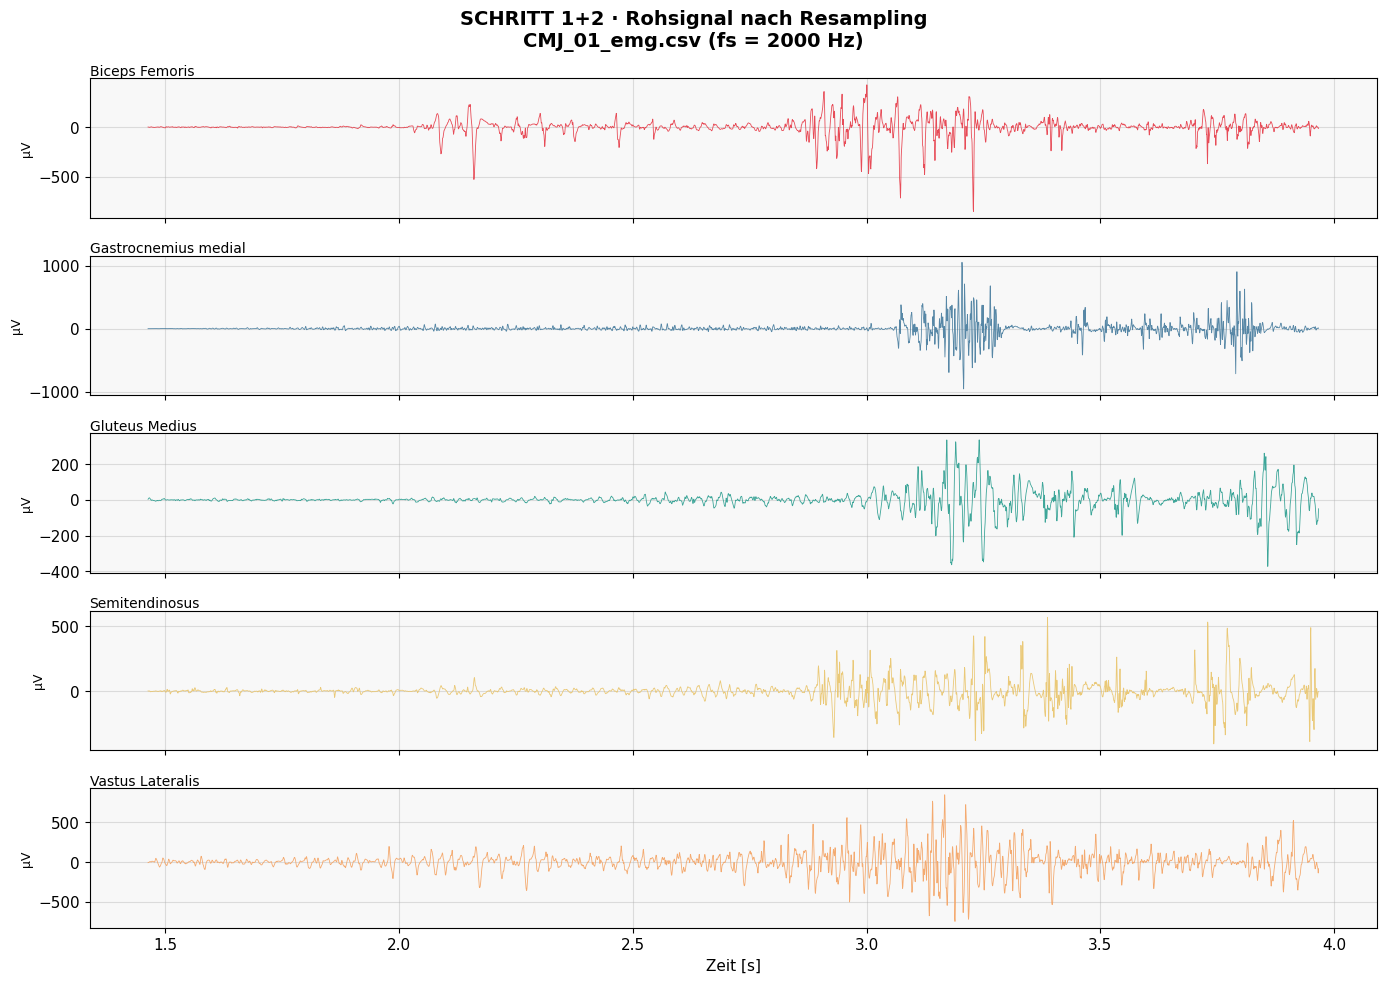

In [12]:
# ─── Plot: Schritt 1+2 – Rohsignal (nach Resampling) ─────────────────────────

if steps:
    emg_cols = [f'{SIDE}_{m}' for m in MUSCLE_NAMES if f'{SIDE}_{m}' in steps['raw'].columns]
    t = steps['raw']['time_s'].values

    fig, axes = plt.subplots(len(emg_cols), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'SCHRITT 1+2 · Rohsignal nach Resampling\n'
                 f'{viz_file.name} (fs = {fs} Hz)', fontsize=14, fontweight='bold')

    for ax, col in zip(axes, emg_cols):
        muscle = col.replace(f'{SIDE}_', '')
        ax.plot(t, steps['raw'][col].values,
                color=MUSCLE_COLORS.get(muscle, 'steelblue'), lw=0.6, alpha=0.9)
        ax.set_ylabel('µV', fontsize=9)
        ax.set_title(muscle, loc='left', fontsize=10, pad=2)

    axes[-1].set_xlabel('Zeit [s]')
    plt.tight_layout()
    plt.show()

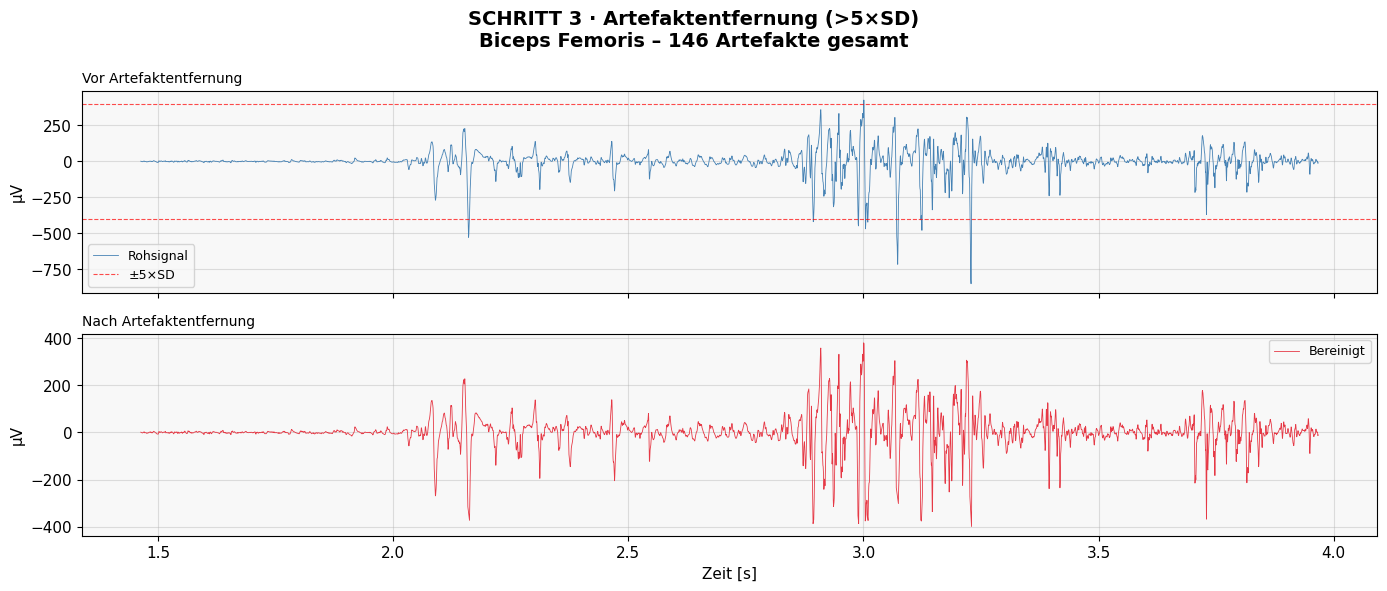

In [13]:
# ─── Plot: Schritt 3 – Artefaktentfernung ────────────────────────────────────

if steps:
    muscle_demo = MUSCLE_NAMES[0]
    col_demo = f'{SIDE}_{muscle_demo}'

    if col_demo in steps['raw'].columns:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
        fig.suptitle(f'SCHRITT 3 · Artefaktentfernung (>{ARTEFACT_SD_FACTOR}×SD)\n'
                     f'{muscle_demo} – {steps["n_artefacts"]} Artefakte gesamt',
                     fontsize=14, fontweight='bold')

        raw_sig = steps['raw'][col_demo].values
        sd = np.std(raw_sig)
        threshold = ARTEFACT_SD_FACTOR * sd

        ax1.plot(t, raw_sig, color='steelblue', lw=0.6, label='Rohsignal')
        ax1.axhline( threshold, color='red', ls='--', lw=0.8, alpha=0.7, label=f'±{ARTEFACT_SD_FACTOR}×SD')
        ax1.axhline(-threshold, color='red', ls='--', lw=0.8, alpha=0.7)
        ax1.set_ylabel('µV')
        ax1.set_title('Vor Artefaktentfernung', loc='left', fontsize=10)
        ax1.legend(fontsize=9)

        ax2.plot(t, steps['clean'][col_demo].values,
                 color=MUSCLE_COLORS.get(muscle_demo, 'steelblue'), lw=0.6, label='Bereinigt')
        ax2.set_ylabel('µV')
        ax2.set_xlabel('Zeit [s]')
        ax2.set_title('Nach Artefaktentfernung', loc='left', fontsize=10)
        ax2.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

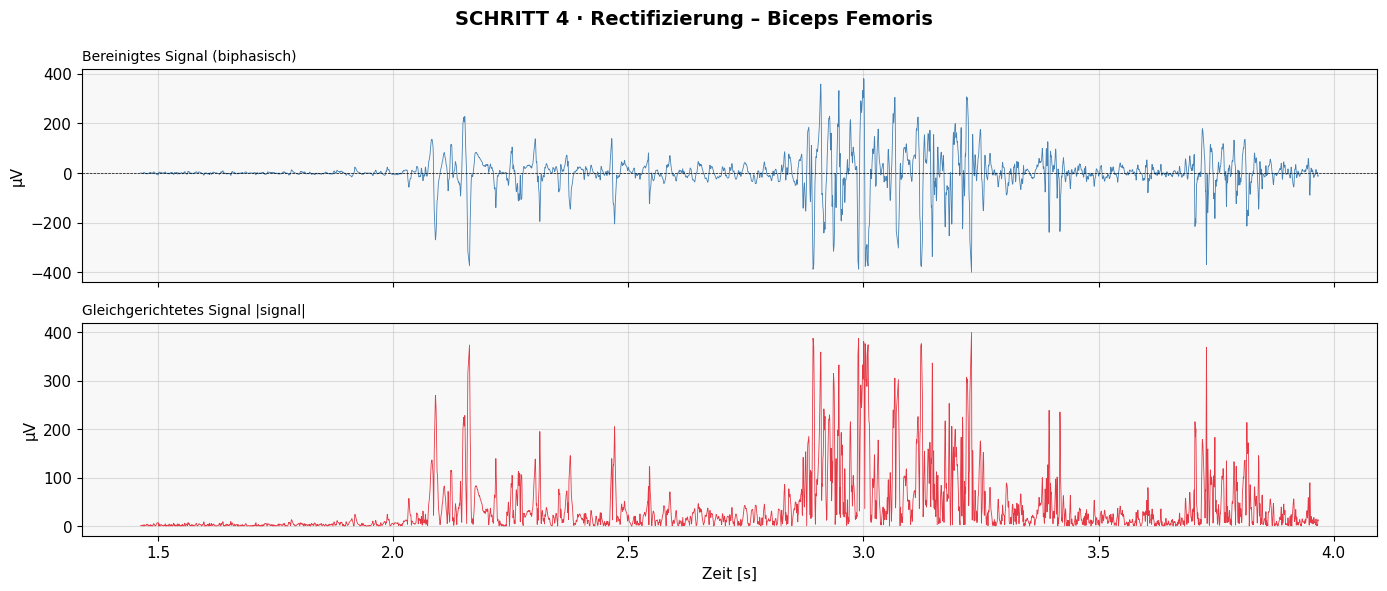

In [14]:
# ─── Plot: Schritt 4 – Rectifizierung ────────────────────────────────────────

if steps and col_demo in steps['clean'].columns:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'SCHRITT 4 · Rectifizierung – {muscle_demo}',
                 fontsize=14, fontweight='bold')

    ax1.plot(t, steps['clean'][col_demo].values, color='steelblue', lw=0.6)
    ax1.axhline(0, color='black', lw=0.5, ls='--')
    ax1.set_ylabel('µV')
    ax1.set_title('Bereinigtes Signal (biphasisch)', loc='left', fontsize=10)

    ax2.plot(t, steps['rect'][col_demo].values,
             color=MUSCLE_COLORS.get(muscle_demo, 'gray'), lw=0.6)
    ax2.set_ylabel('µV')
    ax2.set_xlabel('Zeit [s]')
    ax2.set_title('Gleichgerichtetes Signal |signal|', loc='left', fontsize=10)

    plt.tight_layout()
    plt.show()

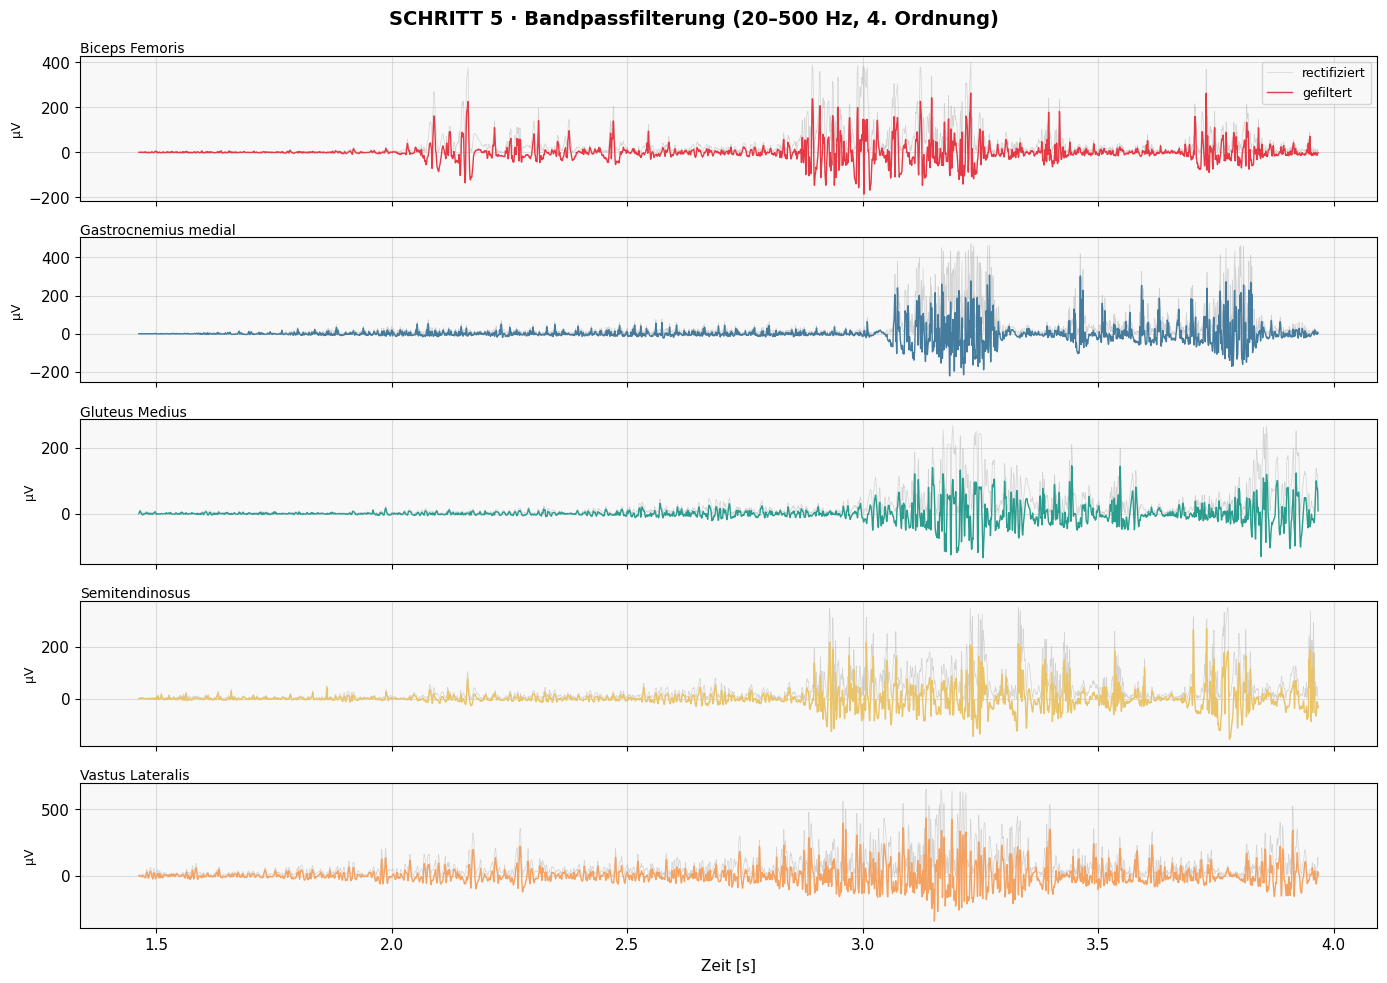

In [15]:
# ─── Plot: Schritt 5 – Bandpassfilter (alle Muskeln) ─────────────────────────

if steps:
    fig, axes = plt.subplots(len(emg_cols), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'SCHRITT 5 · Bandpassfilterung ({BP_LOW}–{BP_HIGH} Hz, '
                 f'{FILTER_ORDER}. Ordnung)', fontsize=14, fontweight='bold')

    for ax, col in zip(axes, emg_cols):
        muscle = col.replace(f'{SIDE}_', '')
        ax.plot(t, steps['rect'][col].values,
                color='lightgray', lw=0.5, label='rectifiziert', zorder=1)
        ax.plot(t, steps['filt'][col].values,
                color=MUSCLE_COLORS.get(muscle, 'blue'), lw=1.0, label='gefiltert', zorder=2)
        ax.set_ylabel('µV', fontsize=9)
        ax.set_title(muscle, loc='left', fontsize=10, pad=2)
        if col == emg_cols[0]:
            ax.legend(fontsize=9, loc='upper right')

    axes[-1].set_xlabel('Zeit [s]')
    plt.tight_layout()
    plt.show()

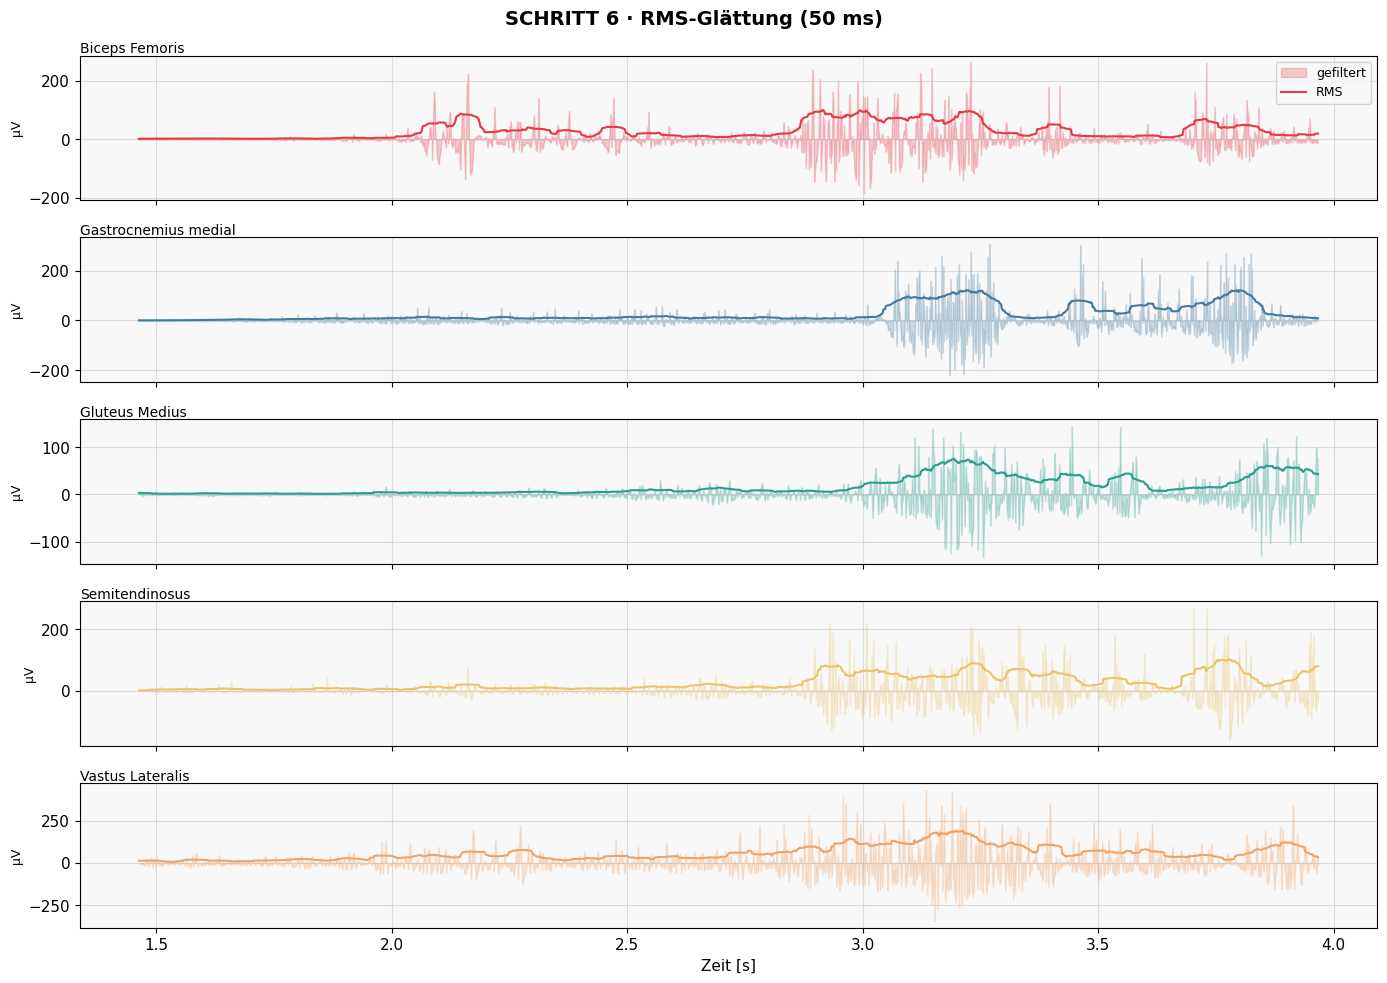

In [16]:
# ─── Plot: Schritt 6 – RMS-Glättung (alle Muskeln) ───────────────────────────

if steps:
    fig, axes = plt.subplots(len(emg_cols), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'SCHRITT 6 · RMS-Glättung ({RMS_WINDOW_MS} ms)',
                 fontsize=14, fontweight='bold')

    for ax, col in zip(axes, emg_cols):
        muscle = col.replace(f'{SIDE}_', '')
        color = MUSCLE_COLORS.get(muscle, 'blue')
        ax.fill_between(t, steps['filt'][col].values,
                        color=color, alpha=0.25, label='gefiltert', zorder=1)
        ax.plot(t, steps['rms'][col].values,
                color=color, lw=1.5, label='RMS', zorder=2)
        ax.set_ylabel('µV', fontsize=9)
        ax.set_title(muscle, loc='left', fontsize=10, pad=2)
        if col == emg_cols[0]:
            ax.legend(fontsize=9, loc='upper right')

    axes[-1].set_xlabel('Zeit [s]')
    plt.tight_layout()
    plt.show()

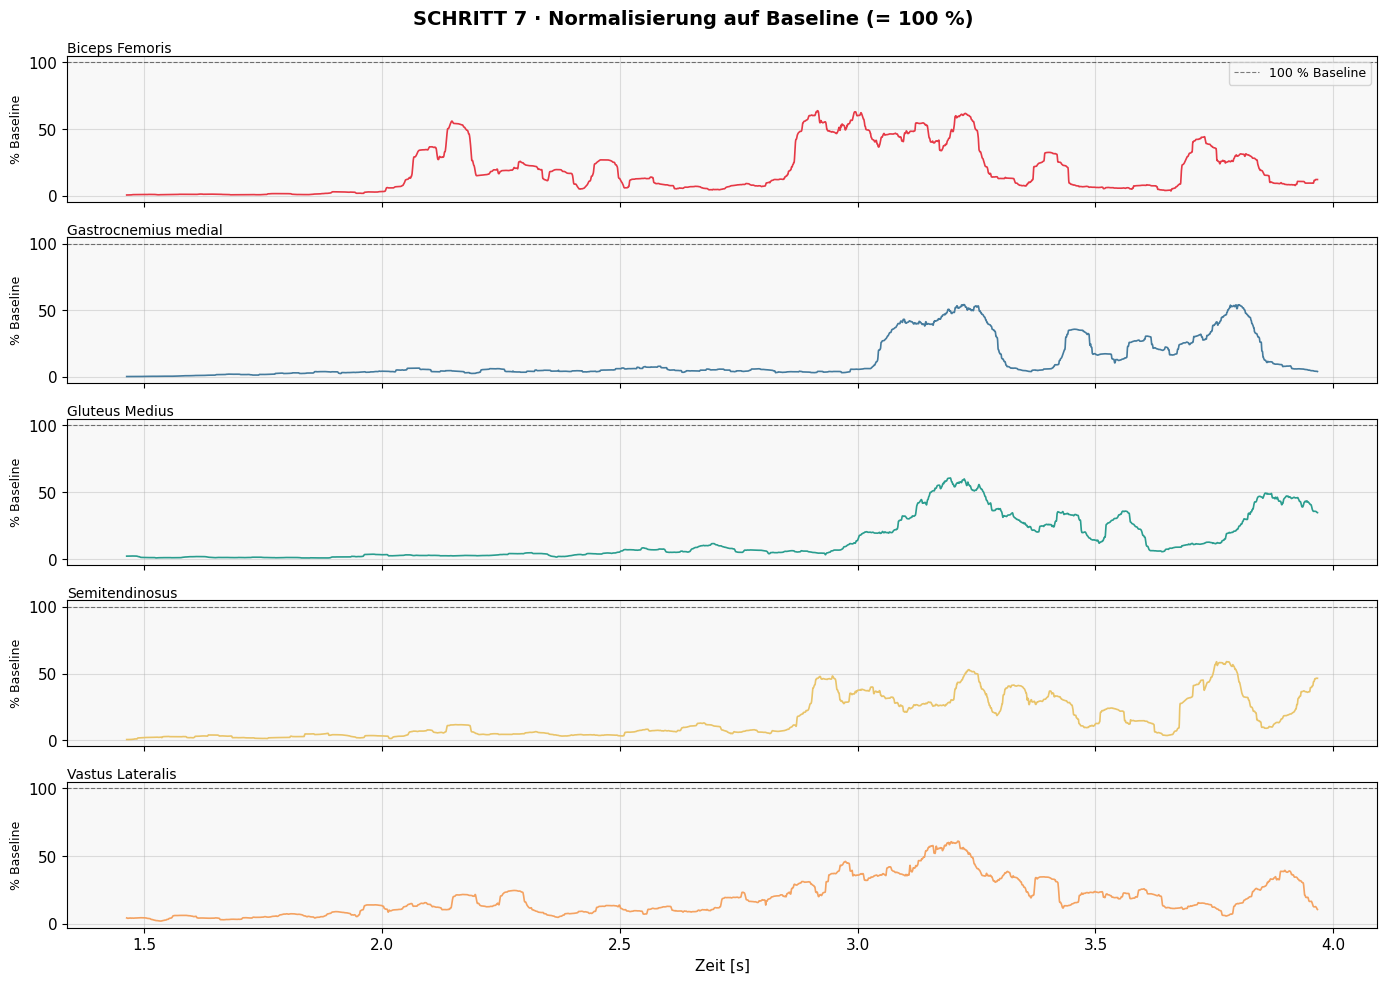

In [17]:
# ─── Plot: Schritt 7 – Normalisierung auf Baseline ────────────────────────

if steps and viz_baseline:
    fig, axes = plt.subplots(len(emg_cols), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'SCHRITT 7 · Normalisierung auf Baseline (= 100 %)',
                 fontsize=14, fontweight='bold')

    for ax, col in zip(axes, emg_cols):
        muscle = col.replace(f'{SIDE}_', '')
        color = MUSCLE_COLORS.get(muscle, 'blue')
        ax.plot(t, steps['normed'][col].values, color=color, lw=1.2)
        ax.axhline(100, color='black', ls='--', lw=0.8, alpha=0.5, label='100 % Baseline')
        ax.set_ylabel('% Baseline', fontsize=9)
        ax.set_title(muscle, loc='left', fontsize=10, pad=2)
        if col == emg_cols[0]:
            ax.legend(fontsize=9, loc='upper right')

    axes[-1].set_xlabel('Zeit [s]')
    plt.tight_layout()
    plt.show()
elif not viz_baseline:
    print('\u26a0\ufe0f  Kein Baseline vorhanden – Normalisierungs-Plot übersprungen')

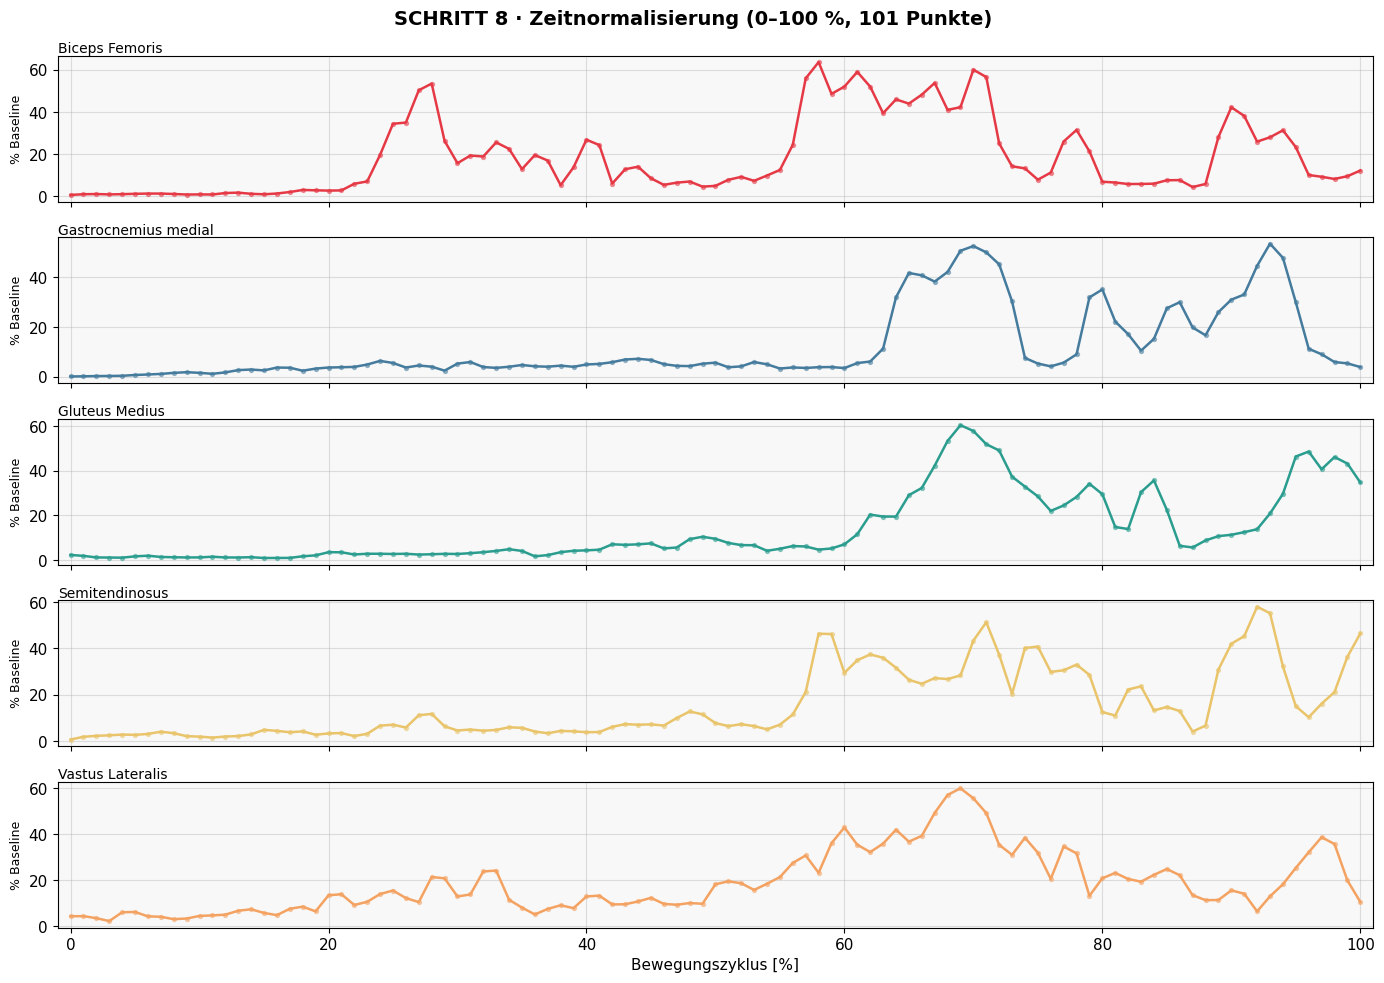

In [18]:
# ─── Plot: Schritt 8 – Zeitnormalisierung ────────────────────────────────────

if steps:
    pct = steps['tnorm']['pct'].values
    ylabel = '% Baseline' if viz_baseline else 'µV'

    fig, axes = plt.subplots(len(emg_cols), 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f'SCHRITT 8 · Zeitnormalisierung (0–100 %, {N_NORM_POINTS} Punkte)',
                 fontsize=14, fontweight='bold')

    for ax, col in zip(axes, emg_cols):
        muscle = col.replace(f'{SIDE}_', '')
        color = MUSCLE_COLORS.get(muscle, 'blue')
        ax.plot(pct, steps['tnorm'][col].values, color=color, lw=1.8)
        ax.scatter(pct, steps['tnorm'][col].values, s=8, color=color, alpha=0.5, zorder=3)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(muscle, loc='left', fontsize=10, pad=2)
        ax.set_xlim(-1, 101)

    axes[-1].set_xlabel('Bewegungszyklus [%]')
    plt.tight_layout()
    plt.show()

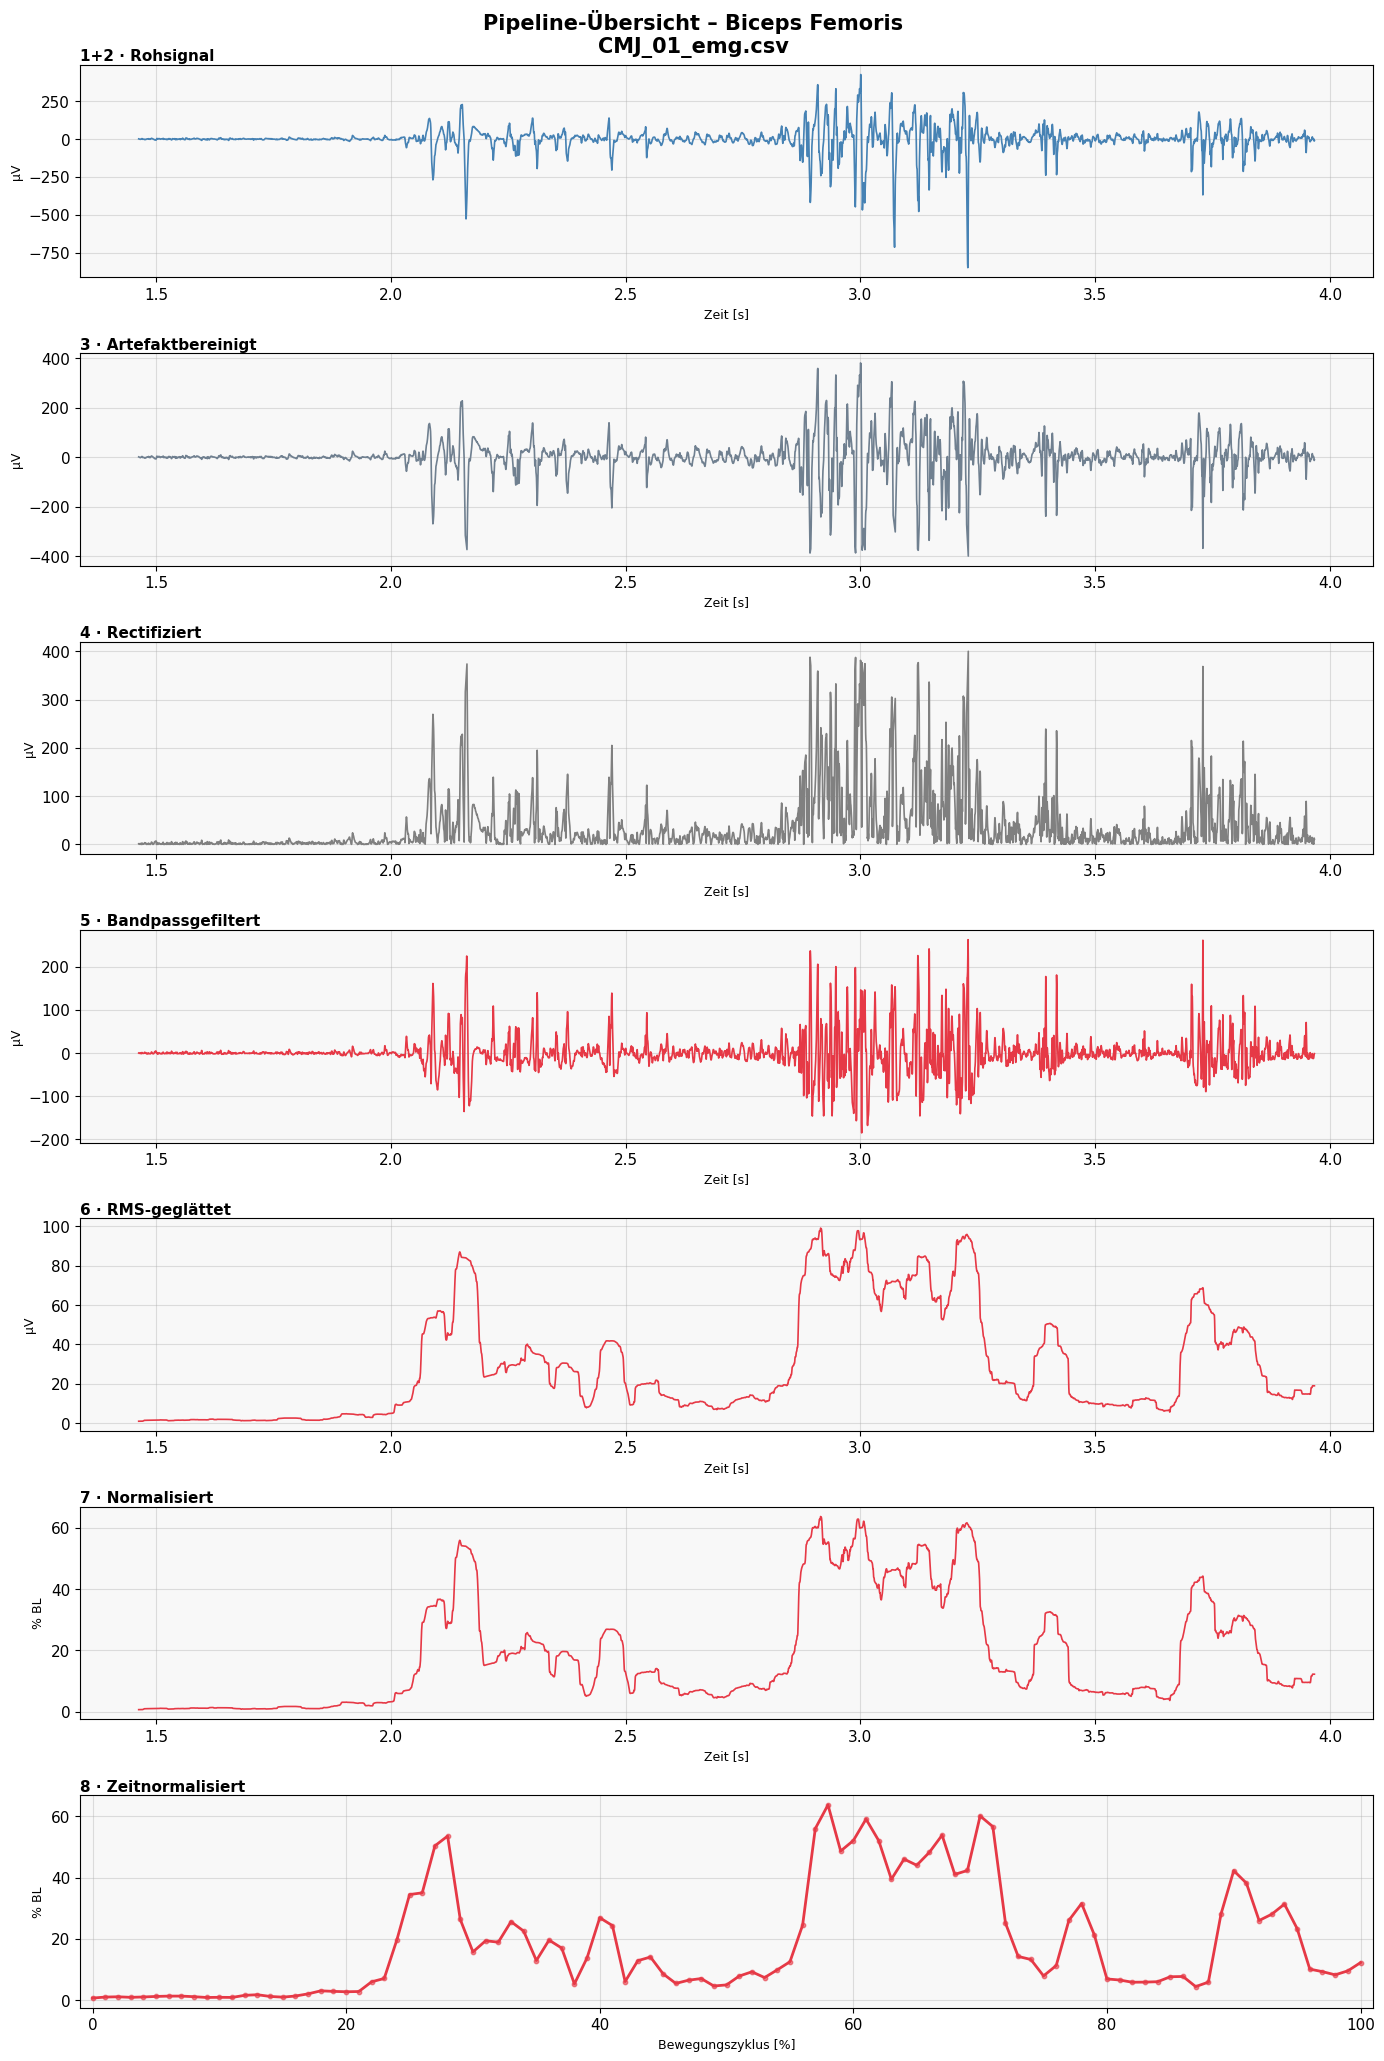

In [19]:
# ─── Übersichtsplot: alle Schritte für einen Muskel ───────────────────────────

if steps and col_demo in steps['raw'].columns:
    color = MUSCLE_COLORS.get(muscle_demo, 'steelblue')
    pct = steps['tnorm']['pct'].values

    plot_steps = [
        ('1+2 · Rohsignal',           t,   steps['raw'][col_demo].values,    'steelblue',  'µV'),
        ('3 · Artefaktbereinigt',      t,   steps['clean'][col_demo].values,  'slategray',  'µV'),
        ('4 · Rectifiziert',           t,   steps['rect'][col_demo].values,   'gray',       'µV'),
        ('5 · Bandpassgefiltert',      t,   steps['filt'][col_demo].values,   color,        'µV'),
        ('6 · RMS-geglättet',          t,   steps['rms'][col_demo].values,    color,        'µV'),
    ]

    if viz_baseline:
        plot_steps.append(
            ('7 · Normalisiert',       t,   steps['normed'][col_demo].values, color,        '% BL')
        )

    plot_steps.append(
        ('8 · Zeitnormalisiert',       pct, steps['tnorm'][col_demo].values,  color,
         '% BL' if viz_baseline else 'µV')
    )

    fig, axes = plt.subplots(len(plot_steps), 1, figsize=(14, 3 * len(plot_steps)))
    fig.suptitle(f'Pipeline-Übersicht – {muscle_demo}\n{viz_file.name}',
                 fontsize=15, fontweight='bold')

    for ax, (title, x, y, c, yl) in zip(axes, plot_steps):
        ax.plot(x, y, color=c, lw=1.2 if 'Zeit' not in title else 2)
        ax.set_title(title, loc='left', fontsize=11, fontweight='bold', pad=3)
        ax.set_ylabel(yl, fontsize=9)
        if 'Zeitnorm' in title:
            ax.scatter(x, y, s=10, color=c, zorder=3, alpha=0.6)
            ax.set_xlim(-1, 101)
            ax.set_xlabel('Bewegungszyklus [%]', fontsize=9)
        else:
            ax.set_xlabel('Zeit [s]', fontsize=9)

    plt.tight_layout()
    plt.show()

---
## Batch-Verarbeitung aller Subjects und Phasen

In [20]:
# ─── Batch: alle Subjects × Phasen × Übungen verarbeiten ─────────────────────
# WICHTIG: Baseline wird PRO PHASE berechnet (phasenspezifisch). Grund u.A.: zwischen den Messterminen werden die Elektroden neu geklebt.

summary = []

for subject in SUBJECTS:
    print(f'\n{"="*65}')
    print(f'{subject}')
    print(f'{"="*65}')

    for phase in PHASES:
        print(f'\n  ── {phase} ──')

         # ── Baseline PRO PHASE berechnen ──────────────────────────────
        baseline = compute_baseline(subject, phase)
        if baseline:
            bl_info = ', '.join(
                f'{k.replace(SIDE+"_","")}={v:.1f}'
                for k, v in baseline.items() if pd.notna(v)
            )
            print(f'  Phasenspezifische Baseline ({BASELINE_MODE}): {bl_info}')
        else:
            print(f'  ⚠️ Keine {BASELINE_MODE}-Baseline für {subject} / {phase}')

        for cfg in EXERCISE_CONFIGS:
            ex    = cfg['exercise']
            side  = cfg['side_folder']
            label = cfg['label']

            trial_dir = DATA_ROOT / subject / phase / ex / side
            if not trial_dir.exists():
                continue

            emg_files = sorted(trial_dir.glob('*_emg.csv'))
            if not emg_files:
                continue

            # Output-Ordner
            out_dir = OUTPUT_DIR / subject / phase / ex / side
            out_dir.mkdir(parents=True, exist_ok=True)

            for filepath in emg_files:
                try:
                    df_result, fs_used, _ = process_trial(filepath, baseline)
                    if df_result is not None:
                        out_name = filepath.stem.replace('_emg', '_processed') + '.csv'
                        out_path = out_dir / out_name
                        df_result.to_csv(out_path, index=False)

                        summary.append({
                            'subject': subject, 'phase': phase,
                            'exercise': label, 'trial': filepath.stem,
                            'status': 'OK', 'fs': fs_used,
                            'baseline': f'{BASELINE_MODE} (phasenspezifisch)',
                        })
                        print(f'✅ {label:16s} {filepath.stem} → {out_name}')
                    else:
                        summary.append({
                            'subject': subject, 'phase': phase,
                            'exercise': label, 'trial': filepath.stem,
                            'status': 'LEER', 'fs': 0, 'baseline': '-',
                        })
                        print(f'⚠️ {label:16s} {filepath.stem} – keine R-Daten')

                except Exception as e:
                    summary.append({
                        'subject': subject, 'phase': phase,
                        'exercise': label, 'trial': filepath.stem,
                        'status': f'FEHLER: {e}', 'fs': 0, 'baseline': '-',
                    })
                    print(f'❌ {label:16s} {filepath.stem} – {e}')

# Zusammenfassung
df_summary = pd.DataFrame(summary)
n_ok    = (df_summary['status'] == 'OK').sum()
n_total = len(df_summary)
n_fail  = n_total - n_ok

print(f'\n{"="*65}')
print(f'BATCH-VERARBEITUNG ABGESCHLOSSEN')
print(f'  Baseline-Modus : {BASELINE_MODE} (phasenspezifisch)')
print(f'  Erfolgreich    : {n_ok} / {n_total}')
print(f'  Fehler/Leer    : {n_fail}')
print(f'  Output         : {OUTPUT_DIR}')
print(f'{"="*65}')


S01

  ── 01_PER ──
    Bester DJ-Trial (01_PER): DJ_01_emg  (Sprunghöhe = 0.199 m)
Baseline 01_PER (Peak-RMS = 100 %):
Biceps Femoris           :   155.47 µV
Gastrocnemius medial     :   224.38 µV
Gluteus Medius           :   122.73 µV
Semitendinosus           :   172.36 µV
Vastus Lateralis         :   311.79 µV
  Phasenspezifische Baseline (DJ): Biceps Femoris=155.5, Gastrocnemius medial=224.4, Gluteus Medius=122.7, Semitendinosus=172.4, Vastus Lateralis=311.8
✅ CMJ bilateral    CMJ_01_emg → CMJ_01_processed.csv
✅ CMJ bilateral    CMJ_02_emg → CMJ_02_processed.csv
✅ CMJ bilateral    CMJ_03_emg → CMJ_03_processed.csv
✅ CMJ einbeinig    CMJ_R_01_emg → CMJ_R_01_processed.csv
✅ CMJ einbeinig    CMJ_R_02_emg → CMJ_R_02_processed.csv
✅ CMJ einbeinig    CMJ_R_03_emg → CMJ_R_03_processed.csv
✅ DJ bilateral     DJ_01_emg → DJ_01_processed.csv
✅ DJ bilateral     DJ_02_emg → DJ_02_processed.csv
✅ DJ bilateral     DJ_03_emg → DJ_03_processed.csv
✅ SQ bilateral     SQ_01_emg → SQ_01_processed.cs

In [21]:
# ─── Zusammenfassungstabelle anzeigen ─────────────────────────────────────────

if not df_summary.empty:
    print('\nVerarbeitete Trials:')
    display(df_summary)


Verarbeitete Trials:


,subject,phase,exercise,trial,status,fs,baseline
0,S01,01_PER,CMJ bilateral,CMJ_01_emg,OK,2000,DJ (phasenspezifisch)
1,S01,01_PER,CMJ bilateral,CMJ_02_emg,OK,2000,DJ (phasenspezifisch)
2,S01,01_PER,CMJ bilateral,CMJ_03_emg,OK,2000,DJ (phasenspezifisch)
3,S01,01_PER,CMJ einbeinig,CMJ_R_01_emg,OK,2000,DJ (phasenspezifisch)
4,S01,01_PER,CMJ einbeinig,CMJ_R_02_emg,OK,2000,DJ (phasenspezifisch)
...,...,...,...,...,...,...,...
450,S11,03_LUT,SQ bilateral,SQ_02_emg,OK,2000,DJ (phasenspezifisch)
451,S11,03_LUT,SQ bilateral,SQ_03_emg,OK,2000,DJ (phasenspezifisch)
452,S11,03_LUT,SQ einbeinig,SQ_R_01_emg,OK,2000,DJ (phasenspezifisch)
453,S11,03_LUT,SQ einbeinig,SQ_R_02_emg,OK,2000,DJ (phasenspezifisch)
